In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
df = pd.read_csv("AI_Traffic_Shield_Bot_Detector.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [6]:
df.head()

,request_count,distinct_paths,path_repeat_ratio,path_entropy,static_asset_ratio,error_rate,not_found_rate,auth_failure_rate,auth_failure_count,distinct_usernames,distinct_user_agents,requests_per_minute,interval_cv,max_depth,distinct_depths,label,profile
0,29.0,8.0,0.724138,2.746419,0.758621,0.0,0.0,0.0,0.0,0.0,1.0,30.003904,1.925237,3.0,4.0,0,human
1,27.0,8.0,0.703704,2.774001,0.740741,0.0,0.0,0.0,0.0,0.0,1.0,37.129237,1.753752,3.0,3.0,0,human
2,13.0,6.0,0.538462,2.507380,0.769231,0.0,0.0,0.0,0.0,0.0,1.0,30.430170,2.093336,3.0,3.0,0,human
3,14.0,7.0,0.500000,2.645593,0.785714,0.0,0.0,0.0,0.0,0.0,1.0,48.927585,2.212128,3.0,3.0,0,human
4,18.0,7.0,0.611111,2.614369,0.777778,0.0,0.0,0.0,0.0,0.0,1.0,29.863925,2.079805,3.0,4.0,0,human


In [7]:
df.tail()

,request_count,distinct_paths,path_repeat_ratio,path_entropy,static_asset_ratio,error_rate,not_found_rate,auth_failure_rate,auth_failure_count,distinct_usernames,distinct_user_agents,requests_per_minute,interval_cv,max_depth,distinct_depths,label,profile
29995,39.0,1.0,0.974359,-0.0,0.0,1.0,0.0,1.0,39.0,1.0,1.0,75.836982,1.126964,3.0,1.0,1,brute_force
29996,22.0,1.0,0.954545,-0.0,0.0,1.0,0.0,1.0,22.0,1.0,1.0,83.863766,1.041881,3.0,1.0,1,brute_force
29997,16.0,1.0,0.937500,-0.0,0.0,1.0,0.0,1.0,16.0,1.0,1.0,90.237970,1.240897,3.0,1.0,1,brute_force
29998,28.0,1.0,0.964286,-0.0,0.0,1.0,0.0,1.0,28.0,1.0,1.0,151.431930,0.299603,3.0,1.0,1,brute_force
29999,35.0,1.0,0.971429,-0.0,0.0,1.0,0.0,1.0,35.0,1.0,1.0,47.110132,1.612469,3.0,1.0,1,brute_force


In [8]:
rows, columns = df.shape

print("Number of observations:", rows)
print("Number of variables:", columns)

Number of observations: 30000
Number of variables: 17


In [9]:
print("Column names:")

for column in df.columns:
    print(column)

Column names:
request_count
distinct_paths
path_repeat_ratio
path_entropy
static_asset_ratio
error_rate
not_found_rate
auth_failure_rate
auth_failure_count
distinct_usernames
distinct_user_agents
requests_per_minute
interval_cv
max_depth
distinct_depths
label
profile


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   request_count         30000 non-null  float64
 1   distinct_paths        30000 non-null  float64
 2   path_repeat_ratio     30000 non-null  float64
 3   path_entropy          30000 non-null  float64
 4   static_asset_ratio    30000 non-null  float64
 5   error_rate            30000 non-null  float64
 6   not_found_rate        30000 non-null  float64
 7   auth_failure_rate     30000 non-null  float64
 8   auth_failure_count    30000 non-null  float64
 9   distinct_usernames    30000 non-null  float64
 10  distinct_user_agents  30000 non-null  float64
 11  requests_per_minute   30000 non-null  float64
 12  interval_cv           30000 non-null  float64
 13  max_depth             30000 non-null  float64
 14  distinct_depths       30000 non-null  float64
 15  label                 30000 no

In [11]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
request_count           0
distinct_paths          0
path_repeat_ratio       0
path_entropy            0
static_asset_ratio      0
error_rate              0
not_found_rate          0
auth_failure_rate       0
auth_failure_count      0
distinct_usernames      0
distinct_user_agents    0
requests_per_minute     0
interval_cv             0
max_depth               0
distinct_depths         0
label                   0
profile                 0
dtype: int64


In [12]:
missing_values[missing_values > 0]

Series([], dtype: int64)

In [13]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [14]:
df.describe()

,request_count,distinct_paths,path_repeat_ratio,path_entropy,static_asset_ratio,error_rate,not_found_rate,auth_failure_rate,auth_failure_count,distinct_usernames,distinct_user_agents,requests_per_minute,interval_cv,max_depth,distinct_depths,label
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.0,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,31.267667,14.575167,0.420381,3.031637,0.280065,0.215327,0.111339,0.083333,2.255933,0.083333,1.0,85.990156,1.089374,2.481900,2.215667,0.583333
std,30.733710,12.423632,0.335111,1.313740,0.327820,0.403372,0.278774,0.276390,7.769657,0.276390,0.0,97.116600,0.578085,0.783768,1.062478,0.493015
min,3.000000,1.000000,0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,3.990419,0.000615,0.000000,1.000000,0.000000
25%,13.000000,7.000000,0.000000,2.584963,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,16.525774,0.606673,2.000000,1.000000,0.000000
50%,24.000000,8.000000,0.500000,2.854030,0.111111,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,42.493642,1.047283,3.000000,2.000000,1.000000
75%,34.000000,23.000000,0.709402,3.700440,0.733333,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,126.102859,1.527891,3.000000,3.000000,1.000000
max,168.000000,49.000000,0.974359,5.614710,0.800000,1.000000,1.000000,1.000000,39.000000,1.000000,1.0,784.741935,2.568605,3.000000,4.000000,1.000000


In [15]:
print("Unique values in label:")
print(df["label"].unique())

print("\nUnique values in profile:")
print(df["profile"].unique())

Unique values in label:
[0 1]

Unique values in profile:
<ArrowStringArray>
[            'human', 'returning_visitor',        'api_client',
           'scraper',    'polite_scraper',  'headless_browser',
           'scanner',       'brute_force']
Length: 8, dtype: str


In [16]:
label_counts = df["label"].value_counts()

print(label_counts)

label
1    17500
0    12500
Name: count, dtype: int64


In [18]:
pd.crosstab(df["label"], df["profile"])

profile,api_client,brute_force,headless_browser,human,polite_scraper,returning_visitor,scanner,scraper
label,,,,,,,,
0,3335,0,0,5830,0,3335,0,0
1,0,2500,3335,0,3335,0,4165,4165


In [22]:
profile_counts = df["profile"].value_counts()

print(profile_counts)

profile
human                5830
scraper              4165
scanner              4165
returning_visitor    3335
api_client           3335
polite_scraper       3335
headless_browser     3335
brute_force          2500
Name: count, dtype: int64


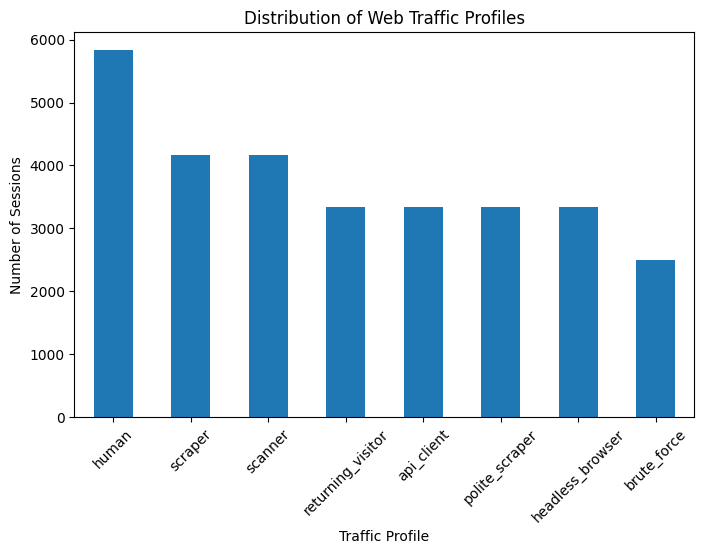

In [23]:
profile_counts.plot(kind="bar", figsize=(8, 5))

plt.title("Distribution of Web Traffic Profiles")
plt.xlabel("Traffic Profile")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=45)

plt.show()

In [24]:
label_counts = df["label"].value_counts()

print(label_counts)

label
1    17500
0    12500
Name: count, dtype: int64


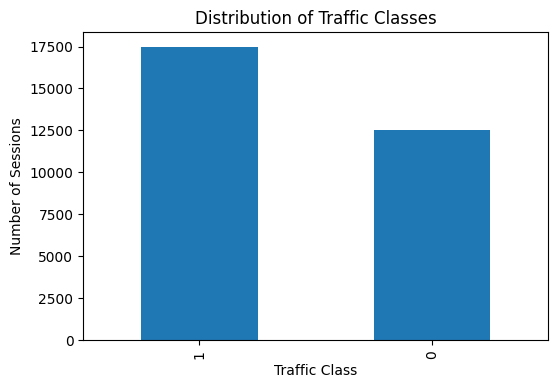

In [25]:
label_counts.plot(kind="bar", figsize=(6, 4))

plt.title("Distribution of Traffic Classes")
plt.xlabel("Traffic Class")
plt.ylabel("Number of Sessions")

plt.show()

In [26]:
label_percentage = df["label"].value_counts(normalize=True) * 100

print("Traffic Class Percentage:")
print(label_percentage)

Traffic Class Percentage:
label
1    58.333333
0    41.666667
Name: proportion, dtype: float64


In [27]:
X = df.drop(columns=["label", "profile"])
y = df["label"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("label")

Features:
['request_count', 'distinct_paths', 'path_repeat_ratio', 'path_entropy', 'static_asset_ratio', 'error_rate', 'not_found_rate', 'auth_failure_rate', 'auth_failure_count', 'distinct_usernames', 'distinct_user_agents', 'requests_per_minute', 'interval_cv', 'max_depth', 'distinct_depths']

Target:
label


In [28]:
statistics = X.describe()

statistics

,request_count,distinct_paths,path_repeat_ratio,path_entropy,static_asset_ratio,error_rate,not_found_rate,auth_failure_rate,auth_failure_count,distinct_usernames,distinct_user_agents,requests_per_minute,interval_cv,max_depth,distinct_depths
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.0,30000.000000,30000.000000,30000.000000,30000.000000
mean,31.267667,14.575167,0.420381,3.031637,0.280065,0.215327,0.111339,0.083333,2.255933,0.083333,1.0,85.990156,1.089374,2.481900,2.215667
std,30.733710,12.423632,0.335111,1.313740,0.327820,0.403372,0.278774,0.276390,7.769657,0.276390,0.0,97.116600,0.578085,0.783768,1.062478
min,3.000000,1.000000,0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,3.990419,0.000615,0.000000,1.000000
25%,13.000000,7.000000,0.000000,2.584963,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,16.525774,0.606673,2.000000,1.000000
50%,24.000000,8.000000,0.500000,2.854030,0.111111,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,42.493642,1.047283,3.000000,2.000000
75%,34.000000,23.000000,0.709402,3.700440,0.733333,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,126.102859,1.527891,3.000000,3.000000
max,168.000000,49.000000,0.974359,5.614710,0.800000,1.000000,1.000000,1.000000,39.000000,1.000000,1.0,784.741935,2.568605,3.000000,4.000000


In [29]:
mean_values = X.mean()

print("Mean of each feature:")
print(mean_values)

Mean of each feature:
request_count           31.267667
distinct_paths          14.575167
path_repeat_ratio        0.420381
path_entropy             3.031637
static_asset_ratio       0.280065
error_rate               0.215327
not_found_rate           0.111339
auth_failure_rate        0.083333
auth_failure_count       2.255933
distinct_usernames       0.083333
distinct_user_agents     1.000000
requests_per_minute     85.990156
interval_cv              1.089374
max_depth                2.481900
distinct_depths          2.215667
dtype: float64


In [31]:
mean_values = X.mean()

print("Mean of each feature:")
print(mean_values)
#Median of Each Feature
median_values = X.median()

print("Median of each feature:")
print(median_values)
#Standard Deviation
std_values = X.std()

print("Standard deviation of each feature:")
print(std_values)

Mean of each feature:
request_count           31.267667
distinct_paths          14.575167
path_repeat_ratio        0.420381
path_entropy             3.031637
static_asset_ratio       0.280065
error_rate               0.215327
not_found_rate           0.111339
auth_failure_rate        0.083333
auth_failure_count       2.255933
distinct_usernames       0.083333
distinct_user_agents     1.000000
requests_per_minute     85.990156
interval_cv              1.089374
max_depth                2.481900
distinct_depths          2.215667
dtype: float64
Median of each feature:
request_count           24.000000
distinct_paths           8.000000
path_repeat_ratio        0.500000
path_entropy             2.854030
static_asset_ratio       0.111111
error_rate               0.000000
not_found_rate           0.000000
auth_failure_rate        0.000000
auth_failure_count       0.000000
distinct_usernames       0.000000
distinct_user_agents     1.000000
requests_per_minute     42.493642
interval_cv          

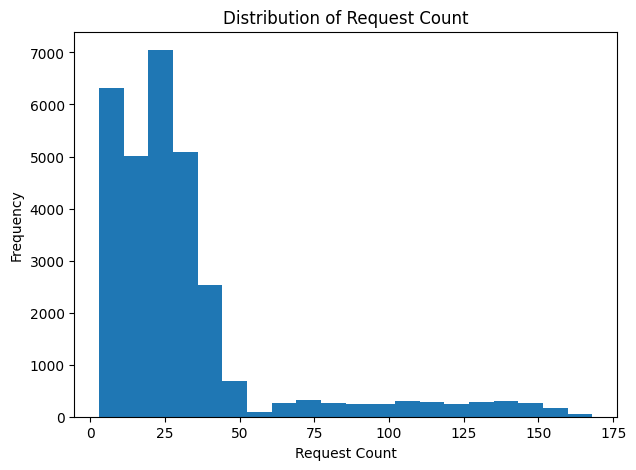

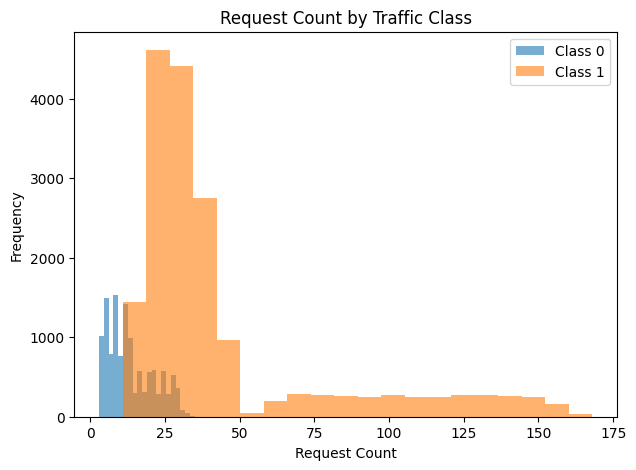

,request_count,distinct_paths,path_repeat_ratio,path_entropy,static_asset_ratio,error_rate,not_found_rate,auth_failure_rate,auth_failure_count,distinct_usernames,distinct_user_agents,requests_per_minute,interval_cv,max_depth,distinct_depths
label,,,,,,,,,,,,,,,
0,13.459520,7.055600,0.352426,2.614782,0.396900,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,20.512220,1.177178,2.776800,2.588080
1,43.987771,19.946286,0.468921,3.329391,0.196612,0.369132,0.190867,0.142857,3.867314,0.142857,1.0,132.760111,1.026657,2.271257,1.949657


In [32]:
plt.figure(figsize=(7, 5))

plt.hist(df["request_count"], bins=20)

plt.title("Distribution of Request Count")
plt.xlabel("Request Count")
plt.ylabel("Frequency")

plt.show()
#Compare Request Count by Traffic Class


human = df[df["label"] == 0]["request_count"]
automated = df[df["label"] == 1]["request_count"]

plt.figure(figsize=(7, 5))

plt.hist(human, bins=20, alpha=0.6, label="Class 0")
plt.hist(automated, bins=20, alpha=0.6, label="Class 1")

plt.title("Request Count by Traffic Class")
plt.xlabel("Request Count")
plt.ylabel("Frequency")

plt.legend()

plt.show()
#Class-wise Mean

class_mean = df.groupby("label")[X.columns].mean()

class_mean

In [33]:
class_median = df.groupby("label")[X.columns].median()

class_median

,request_count,distinct_paths,path_repeat_ratio,path_entropy,static_asset_ratio,error_rate,not_found_rate,auth_failure_rate,auth_failure_count,distinct_usernames,distinct_user_agents,requests_per_minute,interval_cv,max_depth,distinct_depths
label,,,,,,,,,,,,,,,
0,11.0,7.0,0.400000,2.661226,0.333333,0.0,0.0,0.0,0.0,0.0,1.0,11.491464,0.884437,3.0,3.0
1,31.0,20.0,0.672942,3.527384,0.000000,0.0,0.0,0.0,0.0,0.0,1.0,119.899463,1.086538,3.0,2.0


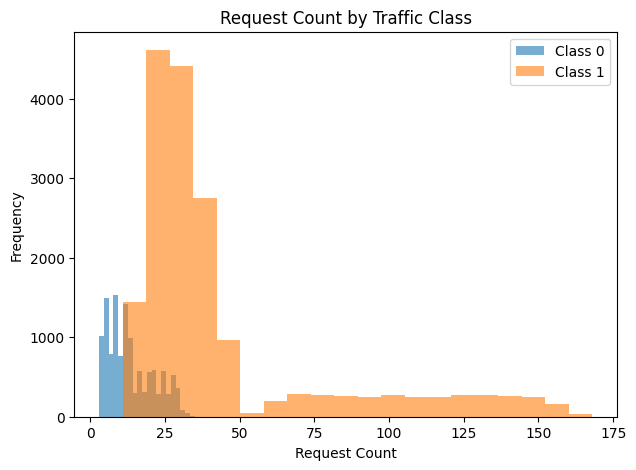

In [34]:
class_0 = df[df["label"] == 0]["request_count"]
class_1 = df[df["label"] == 1]["request_count"]

plt.figure(figsize=(7, 5))

plt.hist(class_0, bins=20, alpha=0.6, label="Class 0")
plt.hist(class_1, bins=20, alpha=0.6, label="Class 1")

plt.title("Request Count by Traffic Class")
plt.xlabel("Request Count")
plt.ylabel("Frequency")
plt.legend()

plt.show()

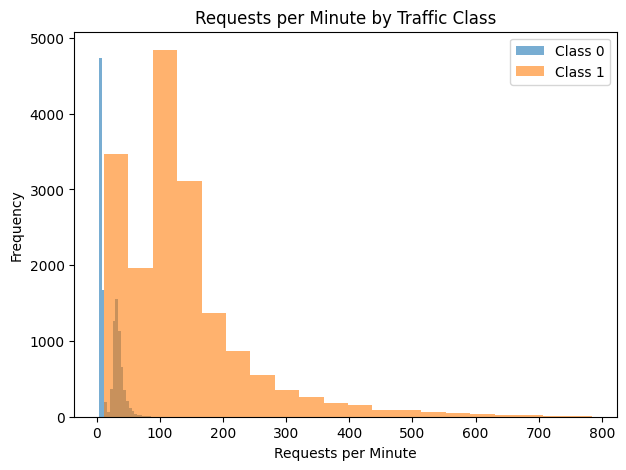

In [35]:
class_0 = df[df["label"] == 0]["requests_per_minute"]
class_1 = df[df["label"] == 1]["requests_per_minute"]

plt.figure(figsize=(7, 5))

plt.hist(class_0, bins=20, alpha=0.6, label="Class 0")
plt.hist(class_1, bins=20, alpha=0.6, label="Class 1")

plt.title("Requests per Minute by Traffic Class")
plt.xlabel("Requests per Minute")
plt.ylabel("Frequency")
plt.legend()

plt.show()

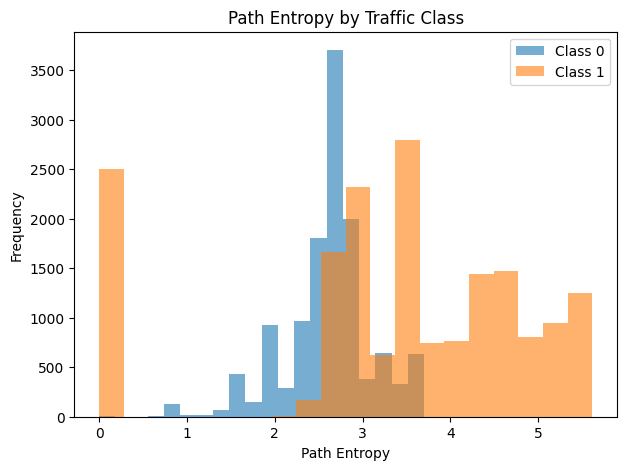

In [36]:
class_0 = df[df["label"] == 0]["path_entropy"]
class_1 = df[df["label"] == 1]["path_entropy"]

plt.figure(figsize=(7, 5))

plt.hist(class_0, bins=20, alpha=0.6, label="Class 0")
plt.hist(class_1, bins=20, alpha=0.6, label="Class 1")

plt.title("Path Entropy by Traffic Class")
plt.xlabel("Path Entropy")
plt.ylabel("Frequency")
plt.legend()

plt.show()

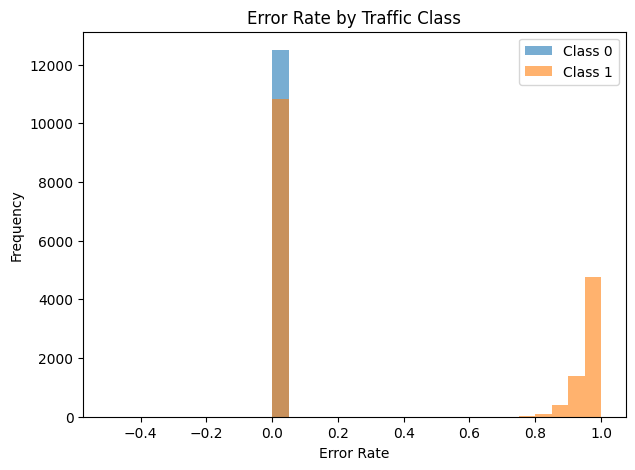

In [37]:
class_0 = df[df["label"] == 0]["error_rate"]
class_1 = df[df["label"] == 1]["error_rate"]

plt.figure(figsize=(7, 5))

plt.hist(class_0, bins=20, alpha=0.6, label="Class 0")
plt.hist(class_1, bins=20, alpha=0.6, label="Class 1")

plt.title("Error Rate by Traffic Class")
plt.xlabel("Error Rate")
plt.ylabel("Frequency")
plt.legend()

plt.show()

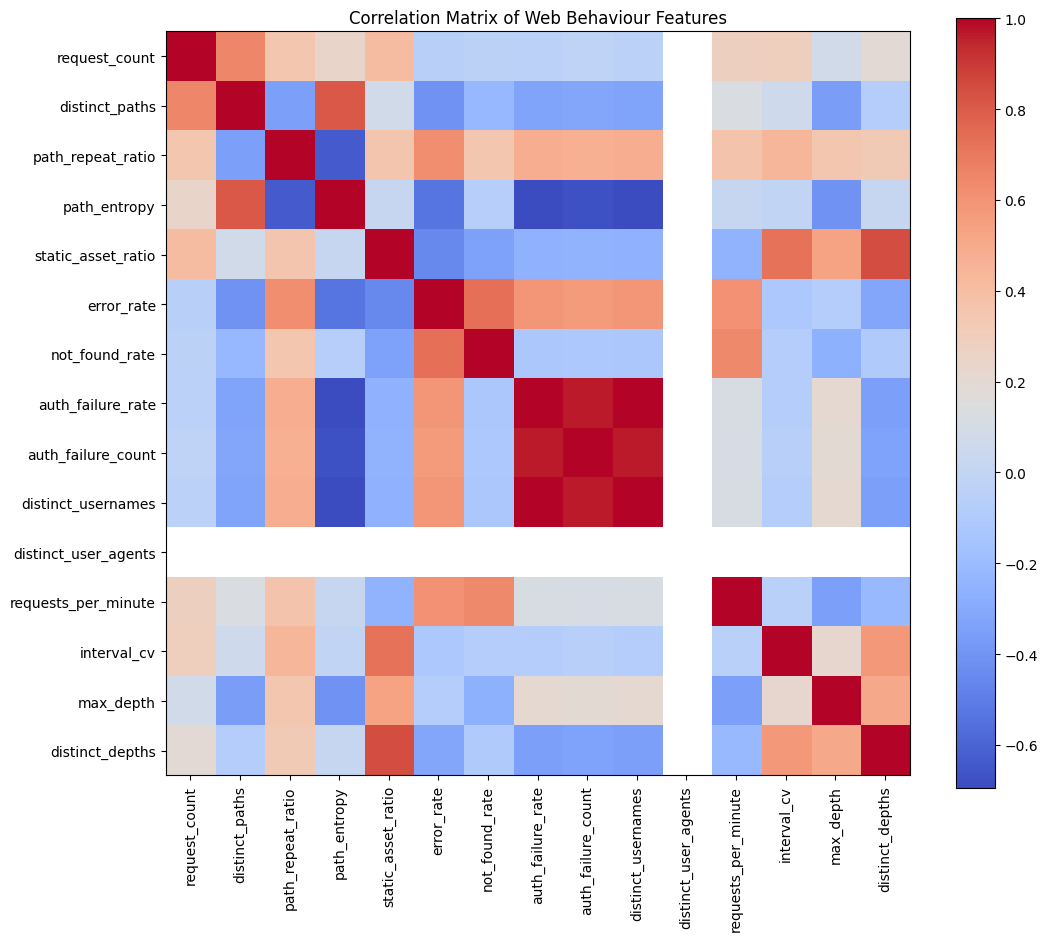

In [38]:
correlation = X.corr()

plt.figure(figsize=(12, 10))

plt.imshow(correlation, cmap="coolwarm")

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix of Web Behaviour Features")

plt.show()

In [39]:
correlation_matrix = X.corr()

correlation_pairs = correlation_matrix.unstack()

correlation_pairs = correlation_pairs[
    correlation_pairs != 1
]

correlation_pairs = correlation_pairs.abs().sort_values(
    ascending=False
)

print(correlation_pairs.head(10))

distinct_usernames  auth_failure_count    0.963004
auth_failure_count  distinct_usernames    0.963004
auth_failure_rate   auth_failure_count    0.963004
auth_failure_count  auth_failure_rate     0.963004
static_asset_ratio  distinct_depths       0.844968
distinct_depths     static_asset_ratio    0.844968
distinct_paths      path_entropy          0.811032
path_entropy        distinct_paths        0.811032
error_rate          not_found_rate        0.729999
not_found_rate      error_rate            0.729999
dtype: float64


In [42]:
X = X.drop(columns=["distinct_user_agents"])

print("Features after removing constant column:")
print(X.columns.tolist())

Features after removing constant column:
['request_count', 'distinct_paths', 'path_repeat_ratio', 'path_entropy', 'static_asset_ratio', 'error_rate', 'not_found_rate', 'auth_failure_rate', 'auth_failure_count', 'distinct_usernames', 'requests_per_minute', 'interval_cv', 'max_depth', 'distinct_depths']


In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (24000, 14)
Testing data: (6000, 14)


In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [45]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

print("Logistic Regression model created!")

Logistic Regression model created!


In [46]:
model.fit(X_train_scaled, y_train)

print("Model training completed!")

Model training completed!


In [47]:
y_pred = model.predict(X_test_scaled)

print("Predictions completed!")
print(y_pred[:20])

Predictions completed!
[1 1 0 1 1 1 1 1 1 1 0 0 1 0 1 0 1 0 0 1]


In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Logistic Regression Performance")
print("--------------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Logistic Regression Performance
--------------------------------
Accuracy : 0.9986666666666667
Precision: 1.0
Recall   : 0.9977142857142857
F1 Score : 0.9988558352402745


In [49]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2500
           1       1.00      1.00      1.00      3500

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



Confusion Matrix:
[[2500    0]
 [   8 3492]]


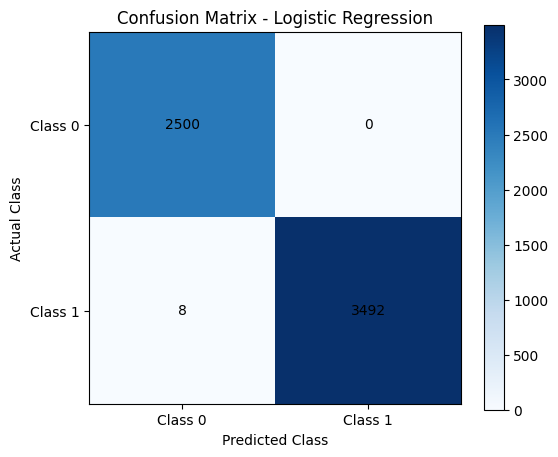

In [51]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)


plt.figure(figsize=(6, 5))

plt.imshow(cm, interpolation="nearest", cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.colorbar()

plt.xticks([0, 1], ["Class 0", "Class 1"])
plt.yticks([0, 1], ["Class 0", "Class 1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [52]:
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Score": [
        accuracy * 100,
        precision * 100,
        recall * 100,
        f1 * 100
    ]
})

results["Score"] = results["Score"].round(2)

results

,Metric,Score
0,Accuracy,99.87
1,Precision,100.00
2,Recall,99.77
3,F1 Score,99.89


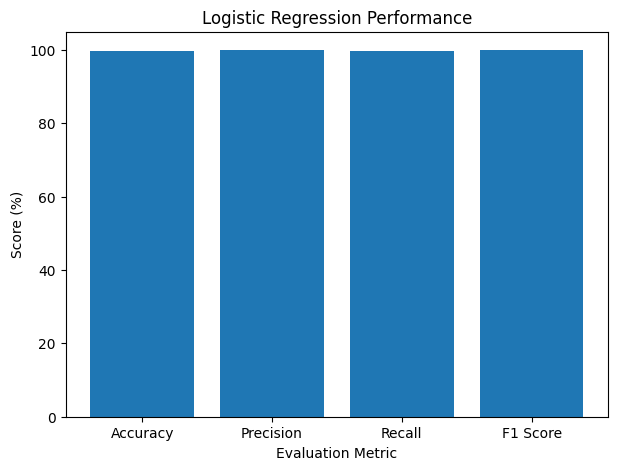

In [53]:
plt.figure(figsize=(7, 5))

plt.bar(results["Metric"], results["Score"])

plt.title("Logistic Regression Performance")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score (%)")
plt.ylim(0, 105)

plt.show()

In [54]:
# Test the model on a few unseen test samples

sample_predictions = model.predict(X_test_scaled[:10])

print("Actual Labels:")
print(y_test.iloc[:10].values)

print("\nPredicted Labels:")
print(sample_predictions)

Actual Labels:
[1 1 0 1 1 1 1 1 1 1]

Predicted Labels:
[1 1 0 1 1 1 1 1 1 1]


In [55]:
# Compare actual and predicted labels

comparison = pd.DataFrame({
    "Actual": y_test.iloc[:10].values,
    "Predicted": sample_predictions
})

comparison["Correct"] = comparison["Actual"] == comparison["Predicted"]

comparison

,Actual,Predicted,Correct
0,1,1,True
1,1,1,True
2,0,0,True
3,1,1,True
4,1,1,True
5,1,1,True
6,1,1,True
7,1,1,True
8,1,1,True
9,1,1,True


In [57]:
# Example of a new traffic session

new_traffic = pd.DataFrame({
    "request_count": [80],
    "distinct_paths": [5],
    "path_repeat_ratio": [0.90],
    "path_entropy": [1.2],
    "static_asset_ratio": [0.05],
    "error_rate": [0.70],
    "not_found_rate": [0.40],
    "auth_failure_rate": [0.60],
    "auth_failure_count": [20],
    "distinct_usernames": [20],
    "requests_per_minute": [300],
    "interval_cv": [0.20],
    "max_depth": [3],
    "distinct_depths": [1]
})

new_traffic_scaled = scaler.transform(new_traffic)

prediction = model.predict(new_traffic_scaled)

print("Predicted Class:", prediction[0])

if prediction[0] == 1:
    print("Prediction: Automated / Bot Traffic")
else:
    print("Prediction: Human Traffic")

Predicted Class: 1
Prediction: Automated / Bot Traffic


In [59]:
# Final Model Summary

print("===== AI Traffic Shield Bot Detector =====")
print()
print("Model: Logistic Regression")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Number of features:", X_train.shape[1])
print()

print("Model Performance:")
print("Accuracy :", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall   :", round(recall * 100, 2), "%")
print("F1 Score :", round(f1 * 100, 2), "%")
print()

print("Confusion Matrix:")
print(cm)
print()

print("New Traffic Prediction:")
print("Predicted Class:", prediction[0])

if prediction[0] == 1:
    print("Result: Automated / Bot Traffic")
else:
    print("Result: Human Traffic")

===== AI Traffic Shield Bot Detector =====

Model: Logistic Regression
Training samples: 24000
Testing samples: 6000
Number of features: 14

Model Performance:
Accuracy : 99.87 %
Precision: 100.0 %
Recall   : 99.77 %
F1 Score : 99.89 %

Confusion Matrix:
[[2500    0]
 [   8 3492]]

New Traffic Prediction:
Predicted Class: 1
Result: Automated / Bot Traffic


In [60]:
#INTREPRETATION 
#The trained Logistic Regression model successfully distinguished between human and automated web traffic using behavioural features.
#It achieved 99.87% accuracy, 100% precision, 99.77% recall, and a 99.89% F1 score on the test dataset. 
#The model also correctly classified a manually constructed high-risk traffic session as automated traffic. 
#These results demonstrate that the selected web-behaviour features can effectively support binary traffic classification within the dataset.

In [61]:
import joblib

# Save trained Logistic Regression model
joblib.dump(model, "bot_detection_model.pkl")

# Save the StandardScaler
joblib.dump(scaler, "bot_detection_scaler.pkl")

print("Model saved as: bot_detection_model.pkl")
print("Scaler saved as: bot_detection_scaler.pkl")

Model saved as: bot_detection_model.pkl
Scaler saved as: bot_detection_scaler.pkl


In [62]:
def predict_traffic(
    request_count,
    distinct_paths,
    path_repeat_ratio,
    path_entropy,
    static_asset_ratio,
    error_rate,
    not_found_rate,
    auth_failure_rate,
    auth_failure_count,
    distinct_usernames,
    requests_per_minute,
    interval_cv,
    max_depth,
    distinct_depths
):
    
    new_data = pd.DataFrame({
        "request_count": [request_count],
        "distinct_paths": [distinct_paths],
        "path_repeat_ratio": [path_repeat_ratio],
        "path_entropy": [path_entropy],
        "static_asset_ratio": [static_asset_ratio],
        "error_rate": [error_rate],
        "not_found_rate": [not_found_rate],
        "auth_failure_rate": [auth_failure_rate],
        "auth_failure_count": [auth_failure_count],
        "distinct_usernames": [distinct_usernames],
        "requests_per_minute": [requests_per_minute],
        "interval_cv": [interval_cv],
        "max_depth": [max_depth],
        "distinct_depths": [distinct_depths]
    })
    
    # Scale the input using the saved scaler
    new_data_scaled = scaler.transform(new_data)
    
    # Predict
    prediction = model.predict(new_data_scaled)[0]
    
    if prediction == 1:
        return "Automated / Bot Traffic"
    else:
        return "Human / Legitimate Traffic"

In [63]:
result = predict_traffic(
    80,      # request_count
    5,       # distinct_paths
    0.90,    # path_repeat_ratio
    1.2,     # path_entropy
    0.05,    # static_asset_ratio
    0.70,    # error_rate
    0.40,    # not_found_rate
    0.60,    # auth_failure_rate
    20,      # auth_failure_count
    20,      # distinct_usernames
    300,     # requests_per_minute
    0.20,    # interval_cv
    3,       # max_depth
    1        # distinct_depths
)

print("Prediction:", result)

Prediction: Automated / Bot Traffic


In [65]:
## Conclusion

#The AI Traffic Shield Bot Detector successfully classified web traffic into human/legitimate and automated/bot traffic using behavioural features.
#A Logistic Regression model was trained on 24,000 samples and evaluated on 6,000 unseen samples using 14 behavioural features. 
#The model achieved 99.87% accuracy, 100% precision, 99.77% recall, and 99.89% F1-score on the test dataset.
#The confusion matrix showed 2,500 correctly classified legitimate traffic samples and 3,492 correctly classified automated traffic samples, 
#with 8 automated traffic samples incorrectly classified as legitimate and no legitimate samples incorrectly classified as automated.
#The model was also tested with a manually constructed high-risk traffic session and correctly identified it as automated/bot traffic.
#Overall, the results demonstrate that behavioural characteristics such as request frequency, path behaviour, error rates,
#authentication failures, and traffic depth can be useful for distinguishing automated web traffic from legitimate traffic.

## Limitations

# The model was evaluated on the available dataset and may not achieve the same performance on real-world traffic.
# The dataset contains predefined traffic profiles, which may not represent every type of real-world bot.
# The model uses aggregated behavioural features rather than raw network packets or complete HTTP logs.
# New or previously unseen bot behaviours may be harder to detect.
# Further validation on real-world or independently collected traffic would be required before production deployment.

## Future Scope

# Integrate the model with real-time web/server logs.
# Build a dashboard for monitoring detected bot traffic.
# Add alert generation for suspicious traffic.
# Extend the system to classify different types of automated traffic.
# Continuously retrain the model using newly observed traffic patterns.
# Integrate the detector into a SOC or web-security monitoring workflow.

In [1]:
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML


# ============================================================
# CSS
# ============================================================

display(HTML("""
<style>

.dashboard-container {
    background: #eaf4ff;
    border: 1px solid #c7def5;
    border-radius: 16px;
    padding: 22px 28px;
    max-width: 900px;
    margin: 15px auto;
    box-sizing: border-box;
}

.dashboard-title {
    text-align: center;
    font-size: 27px;
    font-weight: bold;
    color: #16324f;
    margin: 0 0 3px 0;
}

.dashboard-subtitle {
    text-align: center;
    font-size: 13px;
    color: #5d7185;
    margin: 0 0 18px 0;
}

.section-title {
    font-size: 17px;
    font-weight: bold;
    color: #16324f;
    margin: 0 0 12px 0;
}

.input-label {
    font-size: 12px;
    font-weight: 600;
    color: #334155;
    margin-bottom: 2px;
}

.input-box {
    background: white;
    border: 1px solid #cbd5e1;
    border-radius: 6px;
}

</style>
"""))


# ============================================================
# INPUT CREATOR
# ============================================================

def create_input(label, value):

    label_widget = widgets.HTML(
        value=f"""
        <div class="input-label">
            {label}
        </div>
        """
    )

    input_widget = widgets.FloatText(
        value=value,
        layout=widgets.Layout(
            width="100%",
            height="30px"
        )
    )

    input_widget.add_class("input-box")

    return widgets.VBox(
        [label_widget, input_widget],
        layout=widgets.Layout(
            width="48%",
            margin="0 0 7px 0"
        )
    )


# ============================================================
# INPUT FIELDS
# ============================================================

request_count = create_input("Request Count", 20)

distinct_paths = create_input("Distinct Paths", 10)

path_repeat_ratio = create_input("Path Repeat Ratio", 0.40)

path_entropy = create_input("Path Entropy", 2.5)

static_asset_ratio = create_input("Static Asset Ratio", 0.30)

error_rate = create_input("Error Rate", 0)

not_found_rate = create_input("Not Found Rate", 0)

auth_failure_rate = create_input(
    "Authentication Failure Rate", 0
)

auth_failure_count = create_input(
    "Authentication Failure Count", 0
)

distinct_usernames = create_input(
    "Distinct Usernames", 0
)

requests_per_minute = create_input(
    "Requests Per Minute", 20
)

interval_cv = create_input(
    "Request Interval CV", 1
)

max_depth = create_input(
    "Maximum Path Depth", 3
)

distinct_depths = create_input(
    "Distinct Path Depths", 3
)


# ============================================================
# TWO COLUMN INPUT LAYOUT
# ============================================================

left_column = widgets.VBox(
    [
        request_count,
        distinct_paths,
        path_repeat_ratio,
        path_entropy,
        static_asset_ratio,
        error_rate,
        not_found_rate
    ],
    layout=widgets.Layout(width="48%")
)

right_column = widgets.VBox(
    [
        auth_failure_rate,
        auth_failure_count,
        distinct_usernames,
        requests_per_minute,
        interval_cv,
        max_depth,
        distinct_depths
    ],
    layout=widgets.Layout(width="48%")
)

input_grid = widgets.HBox(
    [left_column, right_column],
    layout=widgets.Layout(
        width="100%",
        justify_content="space-between"
    )
)


# ============================================================
# ANALYZE BUTTON
# ============================================================

analyze_button = widgets.Button(
    description="🔍  ANALYZE TRAFFIC",
    button_style="primary",
    layout=widgets.Layout(
        width="100%",
        height="40px",
        margin="8px 0 8px 0"
    )
)

output = widgets.Output()


# ============================================================
# GET INPUT VALUE
# ============================================================

def get_value(widget):
    return widget.children[1].value


# ============================================================
# ANALYZE FUNCTION
# ============================================================

def analyze_traffic(button):

    with output:

        clear_output()

        result = predict_traffic(

            get_value(request_count),
            get_value(distinct_paths),
            get_value(path_repeat_ratio),
            get_value(path_entropy),
            get_value(static_asset_ratio),
            get_value(error_rate),
            get_value(not_found_rate),
            get_value(auth_failure_rate),
            get_value(auth_failure_count),
            get_value(distinct_usernames),
            get_value(requests_per_minute),
            get_value(interval_cv),
            get_value(max_depth),
            get_value(distinct_depths)
        )


        # ====================================================
        # BOT
        # ====================================================

        if result == "Automated / Bot Traffic":

            display(HTML("""
            <div style="
                background:#fff1f2;
                border:2px solid #dc3545;
                border-radius:10px;
                padding:12px;
                text-align:center;
            ">

                <div style="font-size:25px;">🔴</div>

                <div style="
                    font-size:19px;
                    font-weight:bold;
                    color:#dc3545;
                ">
                    AUTOMATED / BOT TRAFFIC
                </div>

                <div style="
                    color:#555;
                    font-size:12px;
                    margin-top:4px;
                ">
                    Suspicious automated behaviour detected.
                </div>

            </div>
            """))


        # ====================================================
        # HUMAN
        # ====================================================

        else:

            display(HTML("""
            <div style="
                background:#f0fdf4;
                border:2px solid #22c55e;
                border-radius:10px;
                padding:12px;
                text-align:center;
            ">

                <div style="font-size:25px;">🟢</div>

                <div style="
                    font-size:19px;
                    font-weight:bold;
                    color:#16a34a;
                ">
                    HUMAN / LEGITIMATE TRAFFIC
                </div>

                <div style="
                    color:#555;
                    font-size:12px;
                    margin-top:4px;
                ">
                    Traffic appears legitimate.
                </div>

            </div>
            """))


# ============================================================
# BUTTON ACTION
# ============================================================

analyze_button.on_click(analyze_traffic)


# ============================================================
# COMPLETE DASHBOARD
# ============================================================

dashboard = widgets.VBox(

    [

        # Header
        widgets.HTML("""
        <div class="dashboard-title">
            🛡️ AI Traffic Shield
        </div>

        <div class="dashboard-subtitle">
            Automated Web Traffic Detection System
        </div>
        """),

        # Section
        widgets.HTML("""
        <div class="section-title">
            📊 Traffic Behaviour Analysis
        </div>
        """),

        # Inputs
        input_grid,

        # Button
        analyze_button,

        # Result
        output

    ],

    layout=widgets.Layout(
        width="100%"
    )
)


# ============================================================
# LIGHT BLUE OUTER CONTAINER
# ============================================================

container = widgets.Box(
    [dashboard],
    layout=widgets.Layout(
        width="900px",
        margin="15px auto",
        padding="22px 28px",
        border="1px solid #c7def5",
        border_radius="16px",
        background_color="#eaf4ff"
    )
)


display(container)

Box(children=(VBox(children=(HTML(value='\n        <div class="dashboard-title">\n            🛡️ AI Traffic Sh…